# Project: Zuber Ride-Share Market Analysis – Chicago, November 2017

As an analyst for Zuber, a new ride-sharing company entering the Chicago market, my task is to identify key ride patterns, understand passenger behavior, and assess how external factors—particularly weather—affect ride frequency and duration. Using a relational database of taxi trips and weather records, along with provided CSV data, this project includes:

- SQL Analysis: Extracting insights on ride frequency across taxi companies and neighborhoods.

- Data Visualization: Plotting trends in ride volume and drop-off locations.

- Hypothesis Testing: Testing whether ride durations from the Loop to O’Hare differ on rainy Saturdays.

- Tools Used: PostgreSQL (via SQL queries), Python (Pandas, Matplotlib, SciPy), and HTML parsing for weather data.

The insights gained will help inform Zuber's launch strategy and optimize their operations in a competitive market.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from scipy import stats as st

In [2]:
df_01 = pd.read_csv('/datasets/project_sql_result_01.csv')
df_04 = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
print(df_01.head())
print()
print(df_04.head())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [4]:
df_01.info()
print()
df_04.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [13]:
df_01_dup = df_01.duplicated().sum()
print(df_01_dup)

print()

df_04_dup = df_04.duplicated().sum()
print(df_04_dup)

0

0


No duplicates!

Data types are correct!

In [5]:
sorted_neighborhoods = df_04.sort_values(by='average_trips', ascending=False)

top_10 = sorted_neighborhoods.head(10)
print(top_10)

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


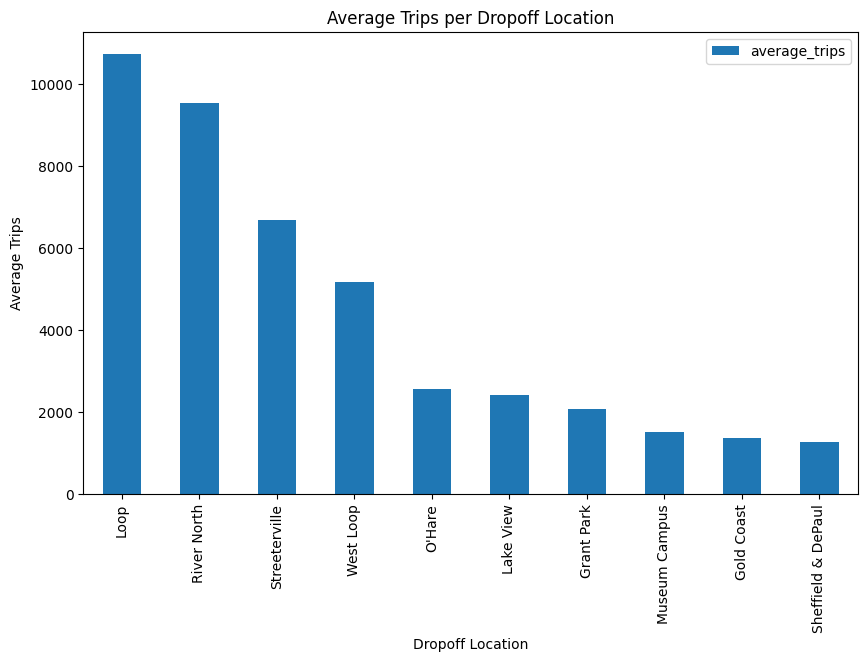

In [6]:
top_10.plot(kind='bar', x= 'dropoff_location_name', y= 'average_trips', figsize=(10,6))

plt.xlabel('Dropoff Location')
plt.ylabel('Average Trips')
plt.title('Average Trips per Dropoff Location')

plt.show()

# Graph 1: Average Trips per Dropoff Location

Top Neighborhoods:

- The neighborhoods with the highest average drop-offs, like "Loop" and "River North," stand out significantly compared to others.
- These neighborhoods likely represent key business, tourist, or entertainment hubs in Chicago, driving higher taxi usage.

Mid-Tier Neighborhoods:

- Neighborhoods like "Streeterville" and "West Loop" also have notable drop-off averages, indicating consistent demand, possibly from residential or mixed-use areas.

Insights:

- The drop-off patterns highlight the importance of these areas for taxi services. Marketing or operational focus on these high-demand areas could improve service efficiency and revenue.

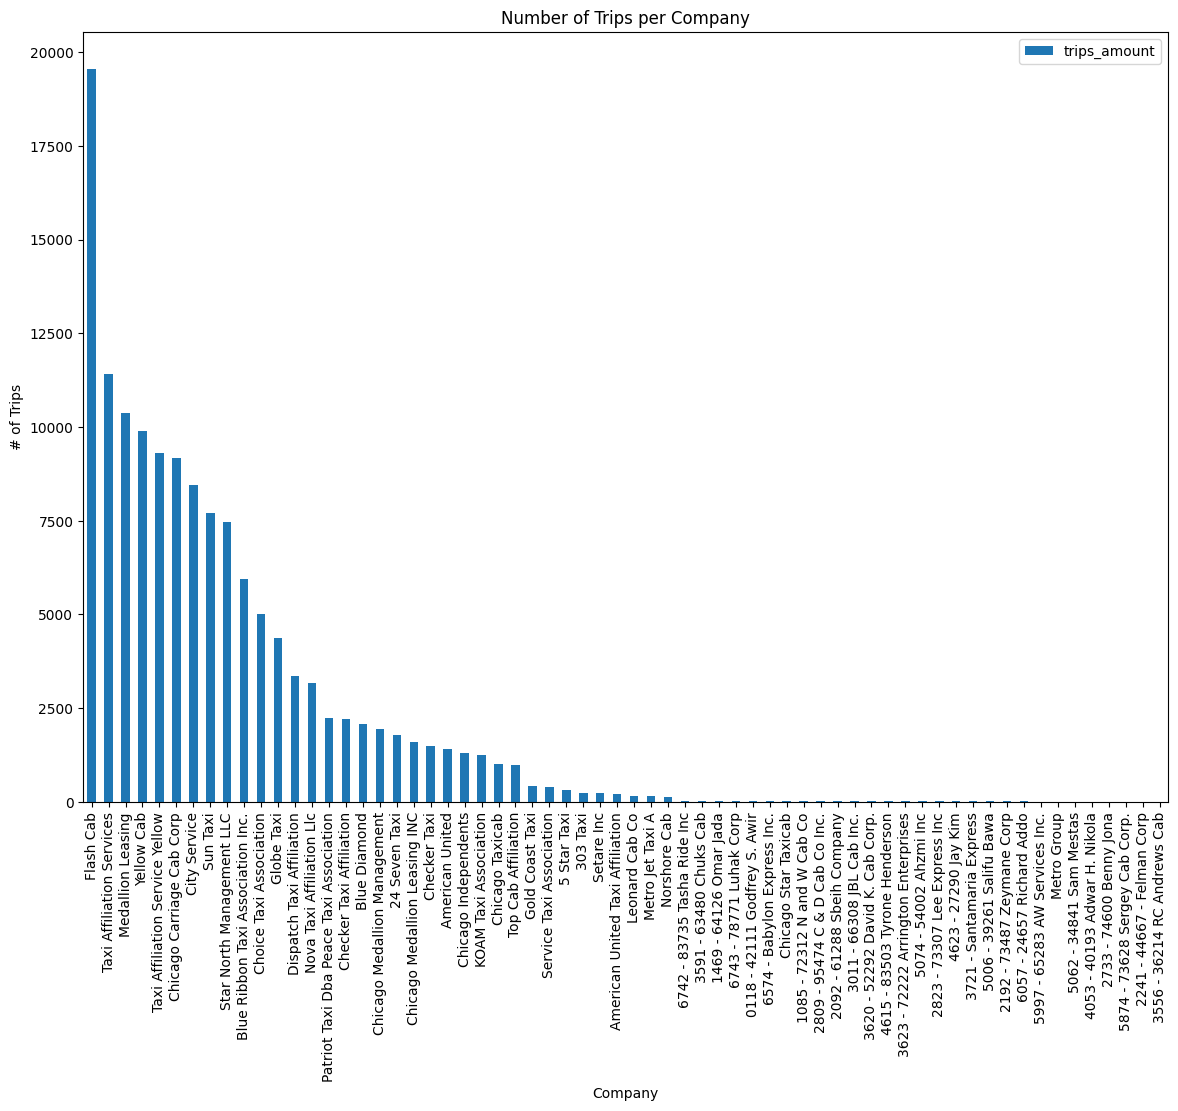

In [15]:
df_01.plot(kind='bar', x= 'company_name', y= 'trips_amount', figsize=(14, 10))

plt.xlabel('Company')
plt.ylabel('# of Trips')
plt.title('Number of Trips per Company')

plt.show()

# Graph 2: Number of Trips per Company

Top Taxi Companies:

- A few companies, such as "Flash Cab" and "Taxi Affiliation Services," dominate the market with a significantly higher number of rides. This reflects market concentration among a few key players.

Smaller Players:

- Many smaller companies have much fewer rides, suggesting they might operate in niche markets or face tough competition.

Insights:

- Companies with fewer trips may need to differentiate their services or focus on underserved areas to compete effectively.

- The dominance of a few companies might indicate an oligopolistic market structure, where a small number of firms control the majority of services.

# Testing Hypotheses

We will now be testing the Hypothesis:

The average duration of rides from the Loop to O'Hare International Airport changes on rainy Saturdays.

- Null Hypothesis: The average duration of rides on rainy Saturdays is equal to the average duration of rides on non-rainy Saturdays.

- Alternative Hypothesis: The average duration of rides on rainy Saturdays is different from the average duration of rides on non-rainy Saturdays.

In [8]:
df_07 = pd.read_csv('/datasets/project_sql_result_07.csv')

print(df_07.head())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0


In [9]:
df_07['start_ts'] = pd.to_datetime(df_07['start_ts'])

df_07['day_of_week'] = df_07['start_ts'].dt.dayofweek

print(df_07.head(25))

              start_ts weather_conditions  duration_seconds  day_of_week
0  2017-11-25 16:00:00               Good            2410.0            5
1  2017-11-25 14:00:00               Good            1920.0            5
2  2017-11-25 12:00:00               Good            1543.0            5
3  2017-11-04 10:00:00               Good            2512.0            5
4  2017-11-11 07:00:00               Good            1440.0            5
5  2017-11-11 04:00:00               Good            1320.0            5
6  2017-11-04 16:00:00                Bad            2969.0            5
7  2017-11-18 11:00:00               Good            2280.0            5
8  2017-11-11 14:00:00               Good            2460.0            5
9  2017-11-11 12:00:00               Good            2040.0            5
10 2017-11-18 06:00:00               Good            1500.0            5
11 2017-11-04 11:00:00               Good            2040.0            5
12 2017-11-11 08:00:00               Good          

Good to know. Every date in our data is a Saturday. 

In [10]:
df_07_good = df_07[df_07['weather_conditions'] == 'Good'].reset_index(drop=True)
print(df_07_good.head(10))

print()

df_07_bad = df_07[df_07['weather_conditions'] == 'Bad'].reset_index(drop=True)
print(df_07_bad.head(10))

             start_ts weather_conditions  duration_seconds  day_of_week
0 2017-11-25 16:00:00               Good            2410.0            5
1 2017-11-25 14:00:00               Good            1920.0            5
2 2017-11-25 12:00:00               Good            1543.0            5
3 2017-11-04 10:00:00               Good            2512.0            5
4 2017-11-11 07:00:00               Good            1440.0            5
5 2017-11-11 04:00:00               Good            1320.0            5
6 2017-11-18 11:00:00               Good            2280.0            5
7 2017-11-11 14:00:00               Good            2460.0            5
8 2017-11-11 12:00:00               Good            2040.0            5
9 2017-11-18 06:00:00               Good            1500.0            5

             start_ts weather_conditions  duration_seconds  day_of_week
0 2017-11-04 16:00:00                Bad            2969.0            5
1 2017-11-18 12:00:00                Bad            1980.0     

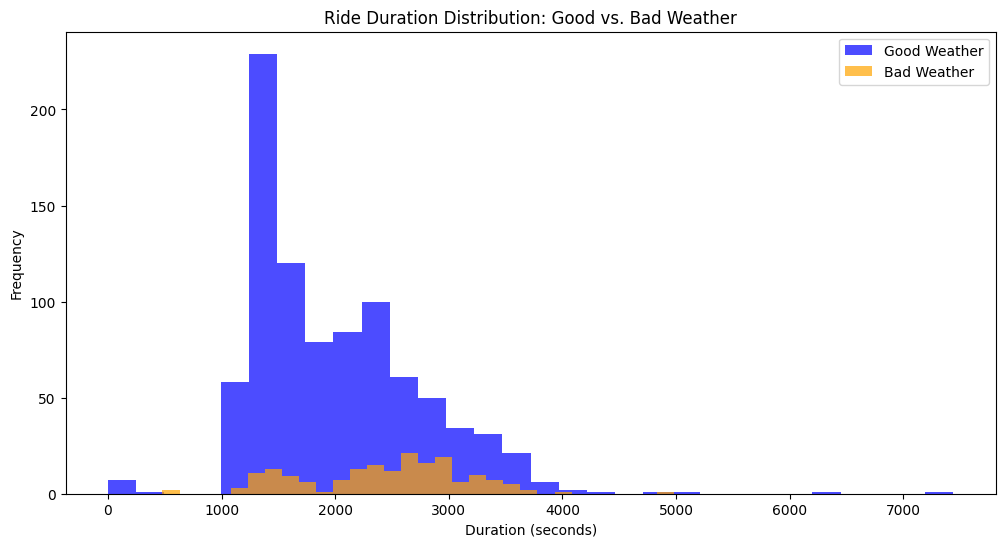

In [11]:
plt.figure(figsize=(12, 6))

plt.hist(df_07_good['duration_seconds'], bins=30, alpha=0.7, label='Good Weather', color='blue')

plt.hist(df_07_bad['duration_seconds'], bins=30, alpha=0.7, label='Bad Weather', color='orange')

plt.title('Ride Duration Distribution: Good vs. Bad Weather')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

# Graph Insights

1. Longer Durations Appear Less Frequent:

Rides with longer durations (e.g., above 4000 seconds) are relatively infrequent in both weather conditions. However, there seems to be a slightly wider spread of durations under "Bad" weather conditions\

2. Overlap Between Conditions:

While the histogram for "Good" weather has a higher overall frequency, the distribution of "Bad" weather overlaps significantly, particularly in the mid-range of durations (1000-3000 seconds). This suggests some similarity in ride durations under the two conditions.

3. Potential Impact of Bad Weather:

Rides during "Bad" weather seem to have slightly more outliers or extended durations compared to "Good" weather, indicating that bad weather might lead to longer travel times for some rides.

Now, let's test our hypothesis:

In [12]:
alpha = 0.05

results = st.ttest_ind(df_07_good['duration_seconds'], df_07_bad['duration_seconds'], equal_var=False)

print('p_value: ', results.pvalue)

if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p_value:  6.738994326108734e-12
We reject the null hypothesis


# Conclusion:
Based on the results of the t-test, we obtained a p-value of approximately 6.74 × 10⁻¹², which is significantly lower than the significance level (α = 0.05). As a result, we reject the null hypothesis.

Interpretation:
There is strong statistical evidence to suggest that the average duration of rides from the Loop to O'Hare International Airport on rainy Saturdays is significantly different from the average duration on non-rainy Saturdays.

Why We Used α = 0.05:
We selected a significance level of 0.05, which is a commonly used threshold in hypothesis testing. It balances the trade-off between Type I errors (rejecting a true null hypothesis) and Type II errors (failing to reject a false null hypothesis), providing a reasonable level of confidence for detecting meaningful differences.

General Conclusion:

- By running EDA on our data, we are able to pinpoint the top neighborhoods and taxi companies. This is important data, as it can allow taxi businesses to understand the competition landscape, and keypoints on where to focus their business. We also found out that there is a statistical significance between the duration of rides on sunny and rainy days. 